# 🚗 Car Price Prediction Project


Jarin Tasnim Rodoshi\
st126736

## Introduction
This project aims to build a machine learning model to predict the selling price of used cars based on various features such as brand, year, fuel type, transmission, mileage, engine capacity, and more. 

## 1. Dataset Loading and Initial Inspection

The required Python libraries are imported: `pandas` for data manipulation, `numpy` for numerical operations, and `matplotlib` for visualization. The dataset is then loaded from `Cars.csv` into a Pandas DataFrame.

Initial inspection is performed to understand the structure, data types, distributions, and data-quality characteristics of the dataset.

**Key steps in this section:**

* The first and last few observations are displayed to examine the raw data.
* The dataset dimensions and column names are inspected.
* Data types and general dataset information are examined using `dtypes()` and `info()`.
* Summary statistics are generated for both numerical and categorical variables.
* Missing values are identified across the dataset.

The dataset initially contains **8,128 observations and 13 columns**. The target variable is `selling_price`, while the remaining columns describe various characteristics of the vehicles.

Several features, including `mileage`, `engine`, `max_power`, and `torque`, are stored as strings containing measurement units. Missing values are also present in several columns. These observations establish the data-cleaning and preprocessing requirements for the subsequent stages.


In [2]:
import pandas as pd

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Cars.csv")

In [5]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [6]:
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0
8127,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [7]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [8]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='str')

In [9]:
df.shape

(8128, 13)

In [10]:
len(df)

8128

In [11]:
df.dtypes


name                 str
year               int64
selling_price      int64
km_driven          int64
fuel                 str
seller_type          str
transmission         str
owner                str
mileage              str
engine               str
max_power            str
torque               str
seats            float64
dtype: object

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [13]:
df.describe(include="all")

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
count,8128,8128.000000,8.128000e+03,8.128000e+03,8128,8128,8128,8128,7907,7907,7913,7906,7907.000000
unique,2058,NaN,NaN,NaN,4,3,2,5,393,121,322,441,NaN
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,NaN
freq,129,NaN,NaN,NaN,4402,6766,7078,5289,225,1017,377,530,NaN
mean,NaN,2013.804011,6.382718e+05,6.981951e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.416719
std,NaN,4.044249,8.062534e+05,5.655055e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.959588
min,NaN,1983.000000,2.999900e+04,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,2011.000000,2.549990e+05,3.500000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,NaN,2015.000000,4.500000e+05,6.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,2017.000000,6.750000e+05,9.800000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000


## 2. Data Cleaning and Preprocessing

The dataset is cleaned to address inconsistent formats, irrelevant categories, and features that are not directly suitable for machine learning.

**Key steps in this section:**

* The `owner` feature is converted from categorical ownership descriptions into ordinal numerical values.
* Vehicles using **LPG and CNG** are removed so that the analysis focuses on Petrol and Diesel vehicles.
* Measurement units are removed from `mileage`, `engine`, and `max_power`, and the extracted values are converted into numerical data types.
* The detailed vehicle `name` is simplified to the manufacturer or brand name by extracting the first component of the original value.
* The `torque` feature is removed because its values have inconsistent formats and are difficult to represent reliably as a single numerical feature.
* `Test Drive Car` observations are removed because they do not represent a normal used-car ownership category.
* The remaining missing values are identified for treatment during the later preprocessing stage.

These operations produce a cleaner dataset with consistently formatted numerical variables and more manageable categorical features, making it suitable for exploratory analysis and subsequent machine learning.


In [14]:
df.owner

0                First Owner
1               Second Owner
2                Third Owner
3                First Owner
4                First Owner
                ...         
8123             First Owner
8124    Fourth & Above Owner
8125             First Owner
8126             First Owner
8127             First Owner
Name: owner, Length: 8128, dtype: str

In [15]:
df ["owner"].unique()

<StringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str

In [16]:
owner_map = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5
}

df["owner"] = df["owner"].map(owner_map)

In [17]:
df ["owner"].unique()

array([1, 2, 3, 4, 5])

In [18]:
df.owner


0       1
1       2
2       3
3       1
4       1
       ..
8123    1
8124    4
8125    1
8126    1
8127    1
Name: owner, Length: 8128, dtype: int64

In [19]:
df.fuel


0       Diesel
1       Diesel
2       Petrol
3       Diesel
4       Petrol
         ...  
8123    Petrol
8124    Diesel
8125    Diesel
8126    Diesel
8127    Diesel
Name: fuel, Length: 8128, dtype: str

In [20]:
df ["fuel"].unique()

<StringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

In [21]:
df = df[~df["fuel"].isin(["LPG", "CNG"])]

In [22]:
df.fuel.unique()

<StringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str

In [23]:
df.mileage


0        23.4 kmpl
1       21.14 kmpl
2        17.7 kmpl
3        23.0 kmpl
4        16.1 kmpl
           ...    
8123     18.5 kmpl
8124     16.8 kmpl
8125     19.3 kmpl
8126    23.57 kmpl
8127    23.57 kmpl
Name: mileage, Length: 8033, dtype: str

In [24]:
df["mileage"] = df["mileage"].str.split().str[0].astype(float)

In [25]:
df ["mileage"].dtype

dtype('float64')

In [26]:
df ["engine"].unique()

<StringArray>
['1248 CC', '1498 CC', '1497 CC', '1396 CC', '1298 CC', '1197 CC',  '796 CC',
 '1364 CC', '1399 CC', '1461 CC',
 ...
 '2197 CC', '2999 CC', '1781 CC', '2650 CC', '1343 CC', '2446 CC', '3498 CC',
 '2198 CC', '2776 CC', '1950 CC']
Length: 122, dtype: str

In [27]:
df ["engine"]=df["engine"].str.split().str[0].astype(float)

In [28]:
df ["engine"].dtype

dtype('float64')

In [29]:
df ['max_power']

0           74 bhp
1       103.52 bhp
2           78 bhp
3           90 bhp
4         88.2 bhp
           ...    
8123     82.85 bhp
8124       110 bhp
8125      73.9 bhp
8126        70 bhp
8127        70 bhp
Name: max_power, Length: 8033, dtype: str

In [30]:
df ["max_power"]=df["max_power"].str.split().str[0].astype(float)


In [31]:
df["name"]

0             Maruti Swift Dzire VDI
1       Skoda Rapid 1.5 TDI Ambition
2           Honda City 2017-2020 EXi
3          Hyundai i20 Sportz Diesel
4             Maruti Swift VXI BSIII
                    ...             
8123               Hyundai i20 Magna
8124           Hyundai Verna CRDi SX
8125          Maruti Swift Dzire ZDi
8126                 Tata Indigo CR4
8127                 Tata Indigo CR4
Name: name, Length: 8033, dtype: str

In [32]:
df ["name"]=df["name"].str.split().str[0].astype(str)

In [33]:
df ["name"]

0        Maruti
1         Skoda
2         Honda
3       Hyundai
4        Maruti
         ...   
8123    Hyundai
8124    Hyundai
8125     Maruti
8126       Tata
8127       Tata
Name: name, Length: 8033, dtype: str

In [34]:
df=df.drop(columns=["torque"])

In [35]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='str')

In [36]:
df.seller_type.unique()

<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

In [37]:
df.engine.unique()

array([1248., 1498., 1497., 1396., 1298., 1197.,  796., 1364., 1399.,
       1461.,  993.,   nan, 1061., 1198., 1199.,  998., 1591., 2179.,
       1368., 2982., 2494., 2143., 2477., 1462., 2755., 1968., 1798.,
       1196., 1373., 1598., 1998., 1086., 1194., 1172., 1405., 1582.,
        999., 2487., 1999., 3604., 2987., 1995., 1451., 1969., 2967.,
       2497., 1797., 1991., 2362., 1493., 1599., 1341., 1794.,  799.,
       1193., 2696., 1495., 1186., 1047., 2498., 2956., 2523., 1120.,
        624., 1496., 1984., 2354.,  814.,  793., 1799.,  936., 1956.,
       1997., 1499., 1948., 2997., 2489., 2499., 2609., 2953., 1150.,
       1994., 1388., 1527., 2199.,  995., 2993., 1586., 1390.,  909.,
       2393., 3198., 1339., 2835., 2092., 1595., 2496., 1596., 1597.,
       2596., 2148., 1299., 1590., 2231., 2694., 2200., 1795., 1896.,
       1796., 1422., 1489., 2359., 2197., 2999., 1781., 2650., 1343.,
       2446., 3498., 2198., 2776., 1950.])

In [38]:
df.dtypes

name                 str
year               int64
selling_price      int64
km_driven          int64
fuel                 str
seller_type          str
transmission         str
owner              int64
mileage          float64
engine           float64
max_power        float64
seats            float64
dtype: object

In [39]:
df.transmission.unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [40]:
df.name.unique()

<StringArray>
[       'Maruti',         'Skoda',         'Honda',       'Hyundai',
        'Toyota',          'Ford',       'Renault',      'Mahindra',
          'Tata',     'Chevrolet',          'Fiat',        'Datsun',
          'Jeep', 'Mercedes-Benz',    'Mitsubishi',          'Audi',
    'Volkswagen',           'BMW',        'Nissan',         'Lexus',
        'Jaguar',          'Land',            'MG',         'Volvo',
        'Daewoo',           'Kia',         'Force',    'Ambassador',
         'Ashok',         'Isuzu',          'Opel',       'Peugeot']
Length: 32, dtype: str

In [41]:
df = df[df["owner"] !=5]

In [42]:
df.owner.unique()

array([1, 2, 3, 4])

In [43]:
df.selling_price

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8123    320000
8124    135000
8125    382000
8126    290000
8127    290000
Name: selling_price, Length: 8028, dtype: int64

In [44]:
y = np.log(df['selling_price'])

In [45]:
y

0       13.017003
1       12.821258
2       11.970350
3       12.323856
4       11.775290
          ...    
8123    12.676076
8124    11.813030
8125    12.853176
8126    12.577636
8127    12.577636
Name: selling_price, Length: 8028, dtype: float64

In [46]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


In [47]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        208
seats            214
dtype: int64

## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distributions of the variables, identify potential data-quality issues, and examine relationships between the predictor variables and the target variable, `selling_price`. Both `seaborn` and `matplotlib` are used to create the visualisations.

### Analysis Performed

The following analyses are conducted:

* **Histograms with KDE:** Used to examine the distributions and skewness of numerical variables such as `selling_price`, `km_driven`, `mileage`, `engine`, `max_power`, and `seats`.
* **Count plots:** Used to examine the frequency of categorical variables, including `fuel`, `name`, `owner`, and `transmission`.
* **Scatter plots:** Used to investigate relationships between numerical predictors such as `km_driven` and `engine` and the target variable, `selling_price`.
* **Box plots:** Used to compare selling-price distributions across categorical variables such as `fuel` and manufacturing years, while also helping identify potential outliers.
* **Grouped count plot:** Used to examine the distribution of transmission types across different fuel types.
* **Correlation heatmap:** Used to examine the linear correlations between numerical variables and identify potentially important relationships with `selling_price`.
* **Pair plot:** Used to examine the pairwise relationships and distributions among the main numerical variables.

### Key Observations

The EDA reveals several important characteristics of the dataset:

* The distribution of **`selling_price` is strongly right-skewed**, with a relatively small number of vehicles having substantially higher prices than the majority of observations. This motivates the use of a logarithmic transformation of the target variable during model development.
* **`km_driven` is also highly right-skewed**, with some vehicles having exceptionally high mileage.
* **`engine` and `max_power` generally show positive relationships with `selling_price`**, suggesting that vehicles with larger engines and greater power tend to have higher selling prices.
* **Vehicle year is positively associated with selling price**, indicating that newer vehicles generally command higher prices than older vehicles.
* The categorical analysis shows that **Diesel and Manual vehicles dominate the dataset**, while other categories have substantially fewer observations.
* The box plot of fuel type indicates differences in the selling-price distributions between **Diesel and Petrol vehicles**.
* The brand-level analysis suggests substantial differences in price distributions across manufacturers, with premium brands such as **BMW and Mercedes-Benz generally occupying higher price ranges**.
* The correlation analysis provides an initial indication of which numerical variables may be useful predictors of vehicle price. However, correlation measures only linear relationships and should therefore not be used as the sole basis for feature selection.

Overall, the EDA indicates that vehicle age, engine characteristics, mileage, brand, and other categorical attributes are likely to contribute to used-car price prediction. The findings also highlight the need for appropriate preprocessing and transformation before model training.


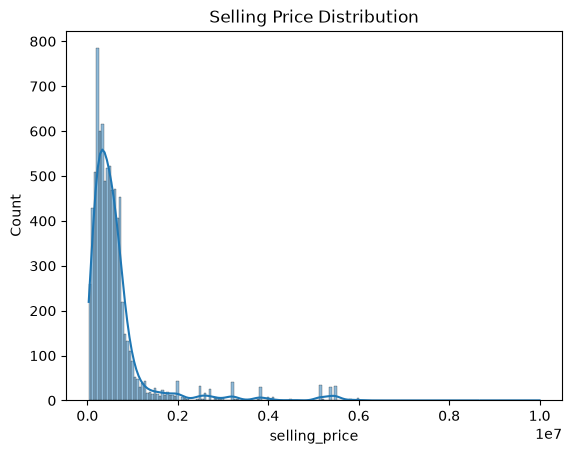

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["selling_price"], kde=True)
plt.title("Selling Price Distribution")
plt.show()

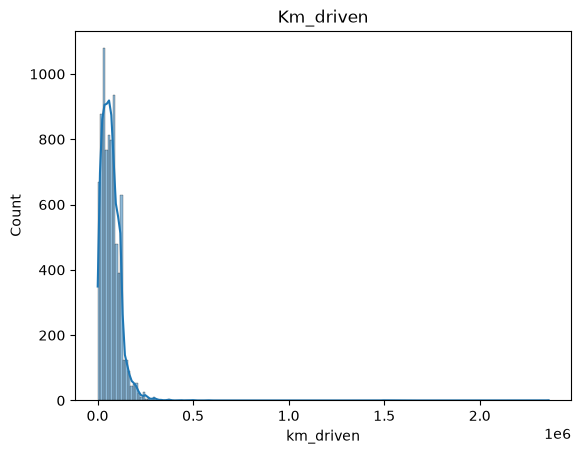

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["km_driven"], kde=True)
plt.title("Km_driven")
plt.show()

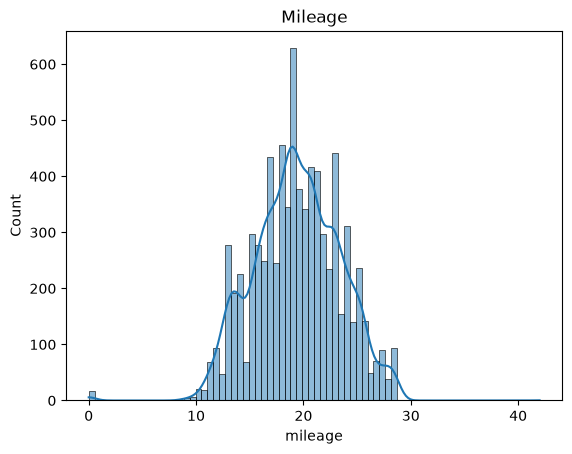

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["mileage"], kde=True)
plt.title("Mileage")
plt.show()

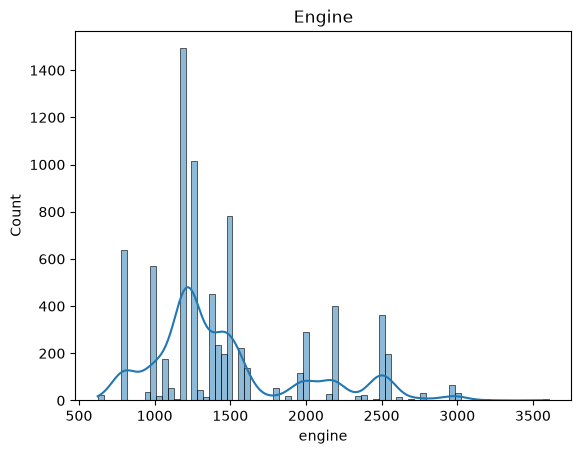

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["engine"], kde=True)
plt.title("Engine")
plt.show()

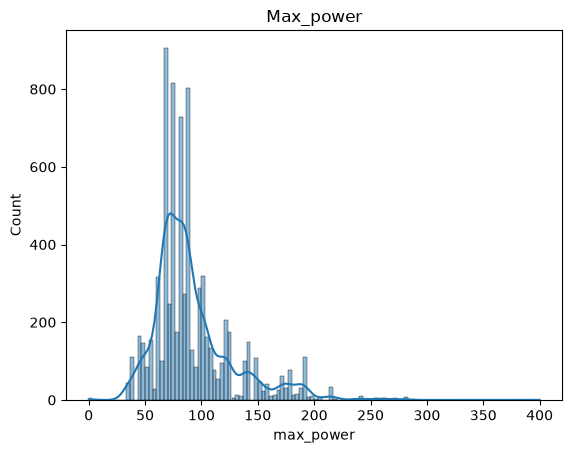

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["max_power"], kde=True)
plt.title("Max_power")
plt.show()

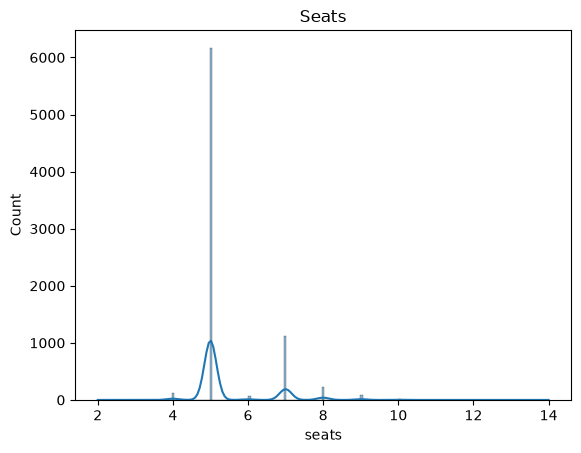

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["seats"], kde=True)
plt.title("Seats")
plt.show()

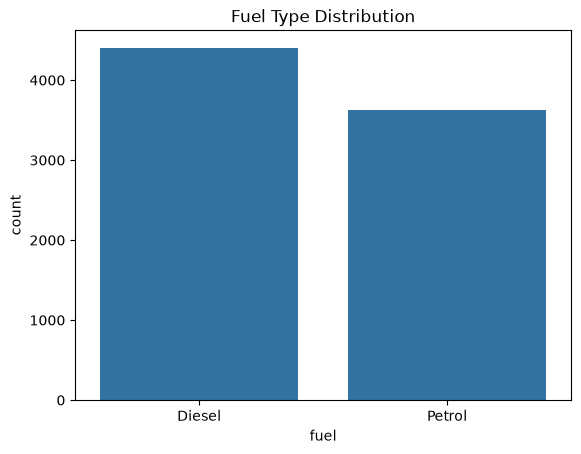

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["fuel"])

plt.title("Fuel Type Distribution")
plt.show()

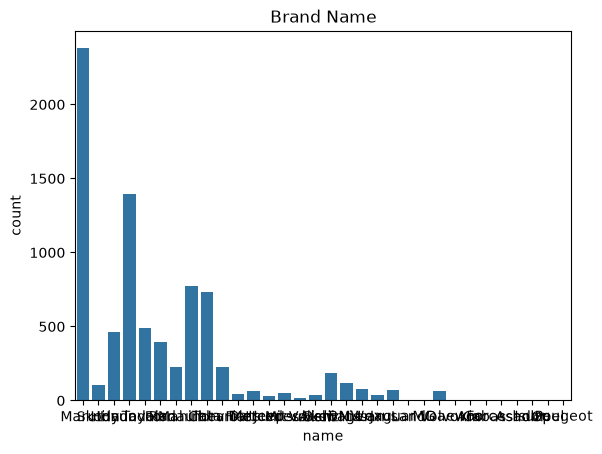

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["name"])

plt.title("Brand Name")
plt.show()

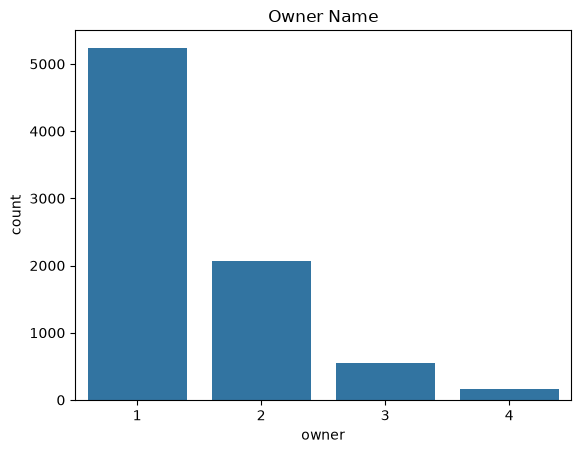

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["owner"])

plt.title("Owner Name")
plt.show()

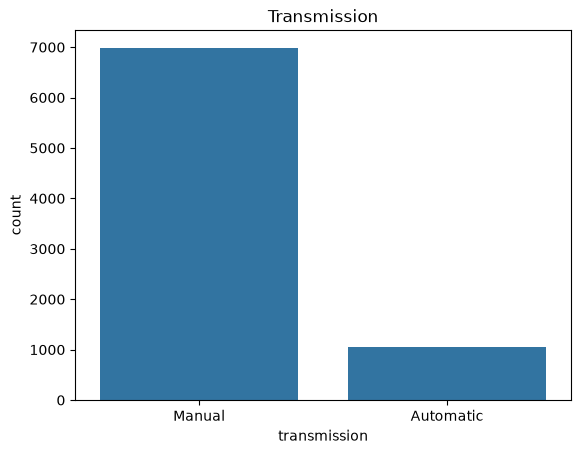

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["transmission"])

plt.title("Transmission")
plt.show()

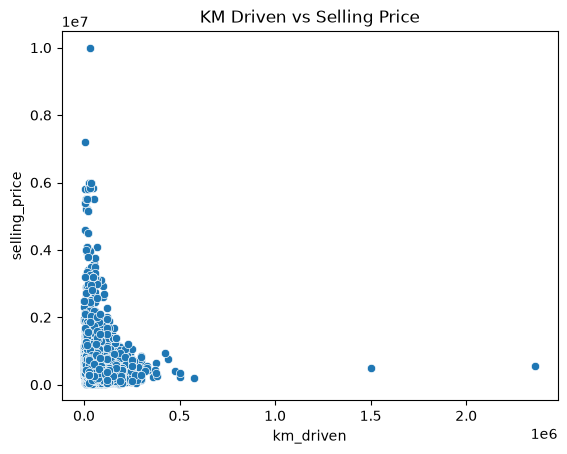

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price"
)

plt.title("KM Driven vs Selling Price")
plt.show()

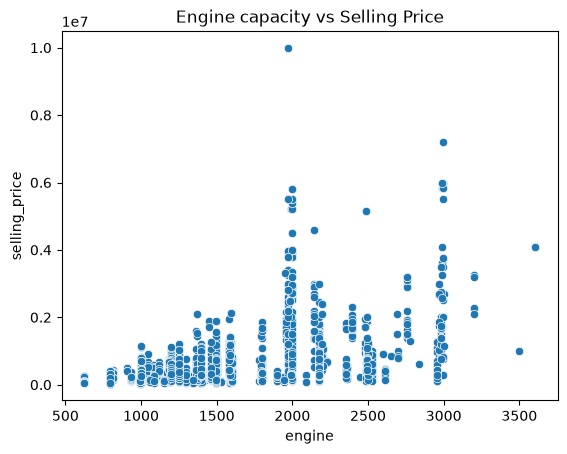

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="engine",
    y="selling_price"
)

plt.title("Engine capacity vs Selling Price")
plt.show()

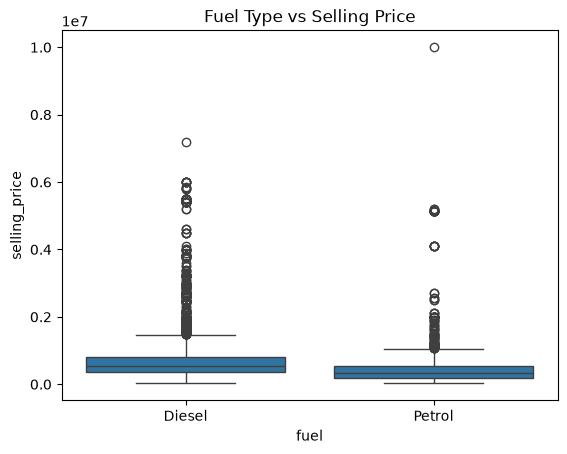

In [60]:
sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

plt.title("Fuel Type vs Selling Price")
plt.show()

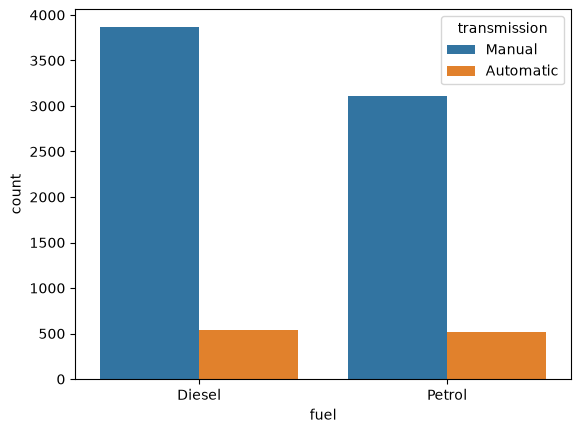

In [61]:
sns.countplot(
    data=df,
    x="fuel",
    hue="transmission"
)

plt.show()

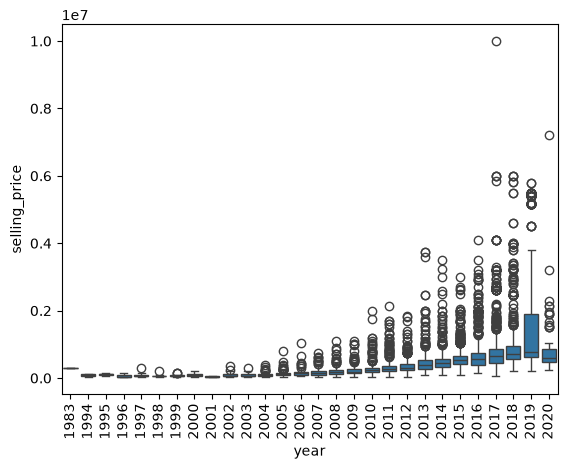

In [62]:
sns.boxplot(
    data=df,
    x="year",
    y="selling_price"
)

plt.xticks(rotation=90)
plt.show()

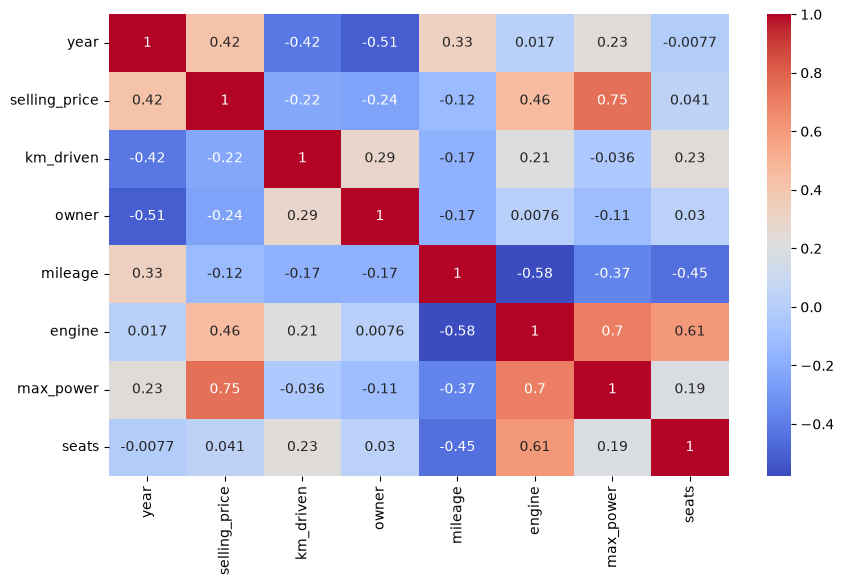

In [63]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

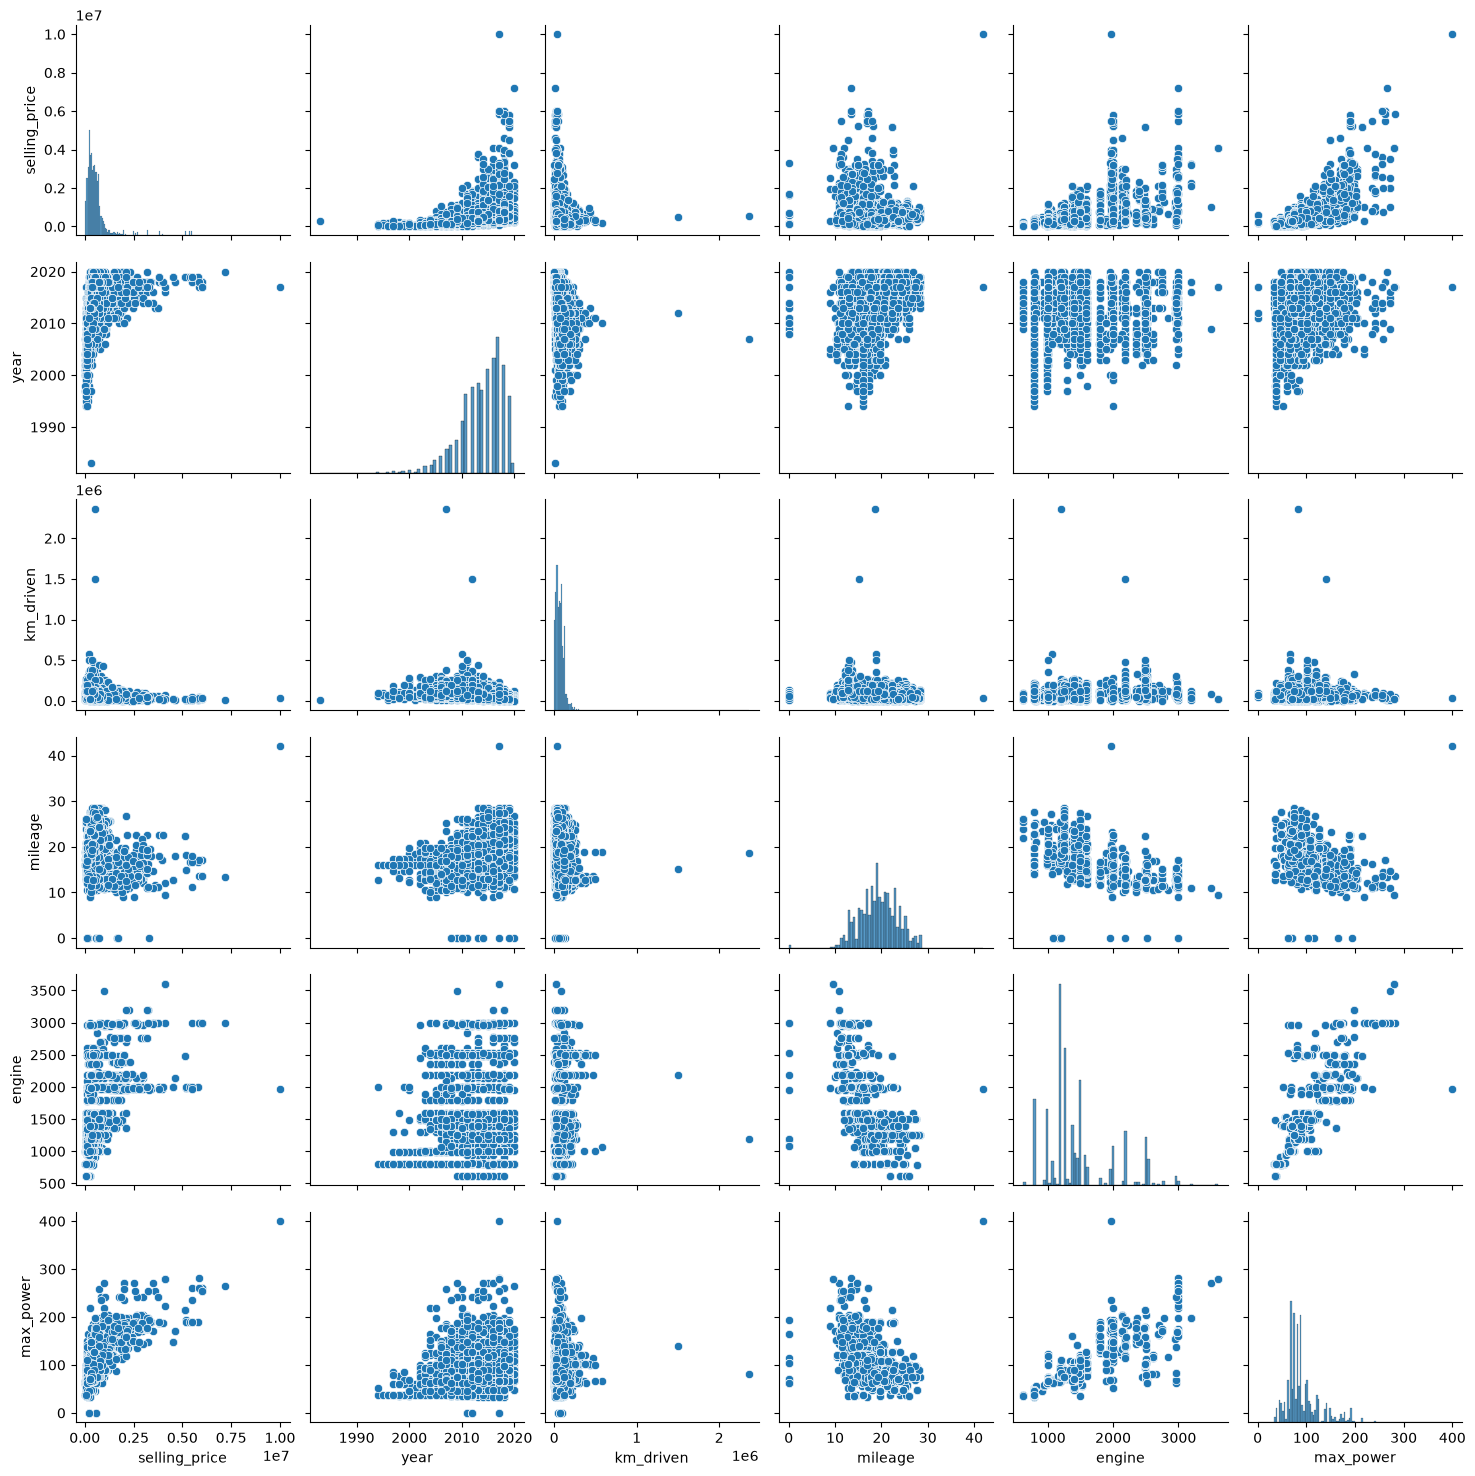

In [64]:
sns.pairplot(
    df[
        [
        "selling_price",
        "year",
        "km_driven",
        "mileage",
        "engine",
        "max_power"
        ]
    ]
)

plt.show()

## 4. Feature Selection and Encoding

The dataset is prepared for machine learning by separating the predictor variables from the target variable and converting categorical features into a numerical representation.

**Key steps in this section:**

* The `selling_price` column is separated from the input features and defined as the **target variable**.
* A **logarithmic transformation** is applied to `selling_price` to reduce its right-skewed distribution and make the target more suitable for regression modeling.
* The categorical features — `name`, `fuel`, `seller_type`, and `transmission` — are identified separately from the numerical features.
* Numerical features include `year`, `km_driven`, `owner`, `mileage`, `engine`, `max_power`, and `seats`.
* **One-hot encoding** is applied to the categorical variables using `pd.get_dummies()`. The `drop_first=True` option removes one category from each categorical feature to avoid redundant dummy variables and reduce potential multicollinearity.
* The resulting encoded dataset, `X_encoded`, contains only numerical/binary features and is therefore suitable for subsequent machine learning algorithms.

This step converts the mixed-type dataset into a machine-learning-ready feature matrix while preserving the information contained in the categorical variables.


In [65]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


In [66]:
X = df.drop("selling_price", axis=1)
y = np.log(df['selling_price'])


In [67]:
cat_cols = [
    "name",
    "fuel",
    "seller_type",
    "transmission"
]

num_cols = [
    "year",
    "km_driven",
    "owner",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

In [68]:
X_encoded = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

In [69]:
X_encoded.shape

(8028, 42)

## 5. Train-Test Split and Missing Value Imputation

The feature matrix and target variable are divided into training and testing subsets before model development. This allows the final model to be evaluated on observations that were not used during training.

An **80:20 train-test split** is used, with 80% of the observations allocated to the training set and 20% to the testing set. `random_state=42` is specified to ensure reproducibility.

After the split, missing values in the numerical features are handled using statistics calculated exclusively from the training data.

**Key steps in this section:**

* Missing `mileage`, `max_power`, and `seats` values are replaced using their respective training-set median values.
* Missing `engine` values are replaced using the training-set mean.
* The same imputation values calculated from the training set are applied to the test set.
* The datasets are checked again to ensure that missing values have been handled successfully.

Using training-set statistics for both datasets prevents information from the test set from influencing the preprocessing stage and helps avoid data leakage.


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [71]:
X_train.head()

,year,km_driven,owner,mileage,engine,max_power,seats,name_Ashok,name_Audi,name_BMW,...,name_Renault,name_Skoda,name_Tata,name_Toyota,name_Volkswagen,name_Volvo,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
2982,2016,59300,1,25.17,799.0,53.30,5.0,False,False,False,...,True,False,False,False,False,False,True,True,False,True
2430,2013,60000,4,22.74,796.0,47.30,5.0,False,False,False,...,False,False,False,False,False,False,True,True,False,True
6294,2009,56000,2,NaN,NaN,NaN,NaN,False,False,False,...,False,False,False,False,False,False,True,False,False,True
6255,2018,50000,1,17.60,2179.0,153.86,7.0,False,False,False,...,False,False,True,False,False,False,False,True,False,True
4253,1999,100000,3,14.80,1998.0,68.00,5.0,False,False,False,...,False,False,False,False,False,False,False,True,False,True


In [72]:
X_train.shape

(6422, 42)

In [73]:
X_test.shape

(1606, 42)

In [74]:
y_train.shape

(6422,)

In [75]:
y_test.shape

(1606,)

In [76]:
X_train.isnull().sum()

year                              0
km_driven                         0
owner                             0
mileage                         171
engine                          171
max_power                       165
seats                           171
name_Ashok                        0
name_Audi                         0
name_BMW                          0
name_Chevrolet                    0
name_Daewoo                       0
name_Datsun                       0
name_Fiat                         0
name_Force                        0
name_Ford                         0
name_Honda                        0
name_Hyundai                      0
name_Isuzu                        0
name_Jaguar                       0
name_Jeep                         0
name_Kia                          0
name_Land                         0
name_Lexus                        0
name_MG                           0
name_Mahindra                     0
name_Maruti                       0
name_Mercedes-Benz          

In [77]:
X_train["mileage"]=X_train["mileage"].fillna(
    X_train["mileage"].median()
)

In [78]:
X_train["engine"]=X_train["engine"].fillna(
    X_train["engine"].mean()
)

In [79]:
X_train["max_power"]=X_train["max_power"].fillna(
    X_train["max_power"].median()
)

In [80]:
X_train["seats"]=X_train["seats"].fillna(
    X_train["seats"].median()
)

In [81]:
X_test["mileage"]=X_test["mileage"].fillna(
    X_train["mileage"].median()
)

In [82]:
X_test["seats"]=X_test["seats"].fillna(
    X_test["seats"].median()
)

In [83]:
X_test["max_power"]=X_test["max_power"].fillna(
    X_test["max_power"].median()
    
)

In [84]:
X_test["engine"]=X_test["engine"].fillna(
    X_test["engine"].mean()
)

In [85]:
y.isnull().sum()

np.int64(0)

## 6. Feature Scaling

Feature scaling is applied to the numerical features to bring them onto a comparable scale. This is particularly important for distance-based and regularized machine learning algorithms, where features with larger numerical ranges can disproportionately influence the model.

**Key steps in this section:**

* `StandardScaler` is used to standardize the numerical features listed in `num_cols`.
* The scaler is **fitted only on the training data** using `fit_transform()`. This calculates the mean and standard deviation from the training set.
* The same fitted scaler is then applied to the test data using `transform()`. This ensures that the test data is scaled using parameters learned exclusively from the training data and prevents data leakage.
* The descriptive statistics of the scaled training features are examined to verify the transformation.
* The dataset is checked again for missing values to ensure that the numerical features are complete before model training.

After standardization, the numerical features have approximately a mean of 0 and a standard deviation of 1, while the categorical features encoded through one-hot encoding remain as binary variables.


In [86]:
from sklearn.preprocessing import StandardScaler


In [87]:
scaler = StandardScaler()

In [88]:
num_cols = [
    "year",
    "km_driven",
    "owner",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

In [89]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

In [90]:
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [91]:
X_train[num_cols].describe()

,year,km_driven,owner,mileage,engine,max_power,seats
count,6.422000e+03,6.422000e+03,6.422000e+03,6.422000e+03,6.422000e+03,6.422000e+03,6.422000e+03
mean,-1.436022e-14,-5.753382e-17,-2.378802e-17,-3.319259e-17,8.630074e-17,-2.157518e-17,-6.306592e-17
std,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00
min,-7.616115e+00,-1.178218e+00,-6.420159e-01,-4.884975e+00,-1.681454e+00,-2.604286e+00,-3.595133e+00
25%,-6.964462e-01,-5.979803e-01,-6.420159e-01,-6.505133e-01,-5.343207e-01,-6.416423e-01,-4.362954e-01
50%,2.920779e-01,-1.713351e-01,-6.420159e-01,-2.038507e-02,-4.322198e-01,-2.476914e-01,-4.362954e-01
75%,7.863400e-01,5.112971e-01,7.733724e-01,6.777970e-01,2.364410e-01,2.970132e-01,-4.362954e-01
max,1.527733e+00,3.908782e+01,3.604149e+00,2.273282e+00,4.284441e+00,5.416953e+00,4.828434e+00


In [92]:
X_train.isnull().sum()

year                            0
km_driven                       0
owner                           0
mileage                         0
engine                          0
max_power                       0
seats                           0
name_Ashok                      0
name_Audi                       0
name_BMW                        0
name_Chevrolet                  0
name_Daewoo                     0
name_Datsun                     0
name_Fiat                       0
name_Force                      0
name_Ford                       0
name_Honda                      0
name_Hyundai                    0
name_Isuzu                      0
name_Jaguar                     0
name_Jeep                       0
name_Kia                        0
name_Land                       0
name_Lexus                      0
name_MG                         0
name_Mahindra                   0
name_Maruti                     0
name_Mercedes-Benz              0
name_Mitsubishi                 0
name_Nissan   

## 7. Linear Regression Baseline Model

Linear Regression is used as a baseline model to establish an initial benchmark for predicting used-car selling prices.

The model is trained using the prepared training features and the log-transformed target variable. Predictions are then generated for the unseen test set.

The fitted model's **intercept and feature coefficients** are examined to understand the direction and magnitude of the relationships learned by the linear model.

Model performance is evaluated using:

* **MAE (Mean Absolute Error)** — measures the average absolute prediction error.
* **MSE (Mean Squared Error)** — measures the average squared prediction error and gives greater weight to larger errors.
* **RMSE (Root Mean Squared Error)** — represents the square root of MSE.
* **R² Score** — measures the proportion of variation in the target variable explained by the model.

Both training and testing R² scores are examined to assess model fit and generalisation.

A comparison between actual and predicted values is also generated to inspect individual predictions.

> **Note:** Because the target variable is log-transformed using `np.log(selling_price)`, the MAE, MSE, and RMSE values at this stage are measured in log-price space.




In [93]:
from sklearn.linear_model import LinearRegression

In [94]:
model = LinearRegression()

In [95]:
model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](42,)","[ 0.46,-0.02,-0.05,...,-0.04,-0.02,-0.07]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](42,)","['year','km_driven','owner',...,'seller_type_Individual', 'seller_type_Trustmark Dealer','transmission_Manual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.46
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,42
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(40)


In [96]:
y_pred=model.predict(X_test)

In [97]:
print (y_pred)

[12.09477386 13.64555582 12.75676252 ... 10.94045126 13.34823585
 12.80140198]


In [98]:
model.coef_

array([ 4.62057772e-01, -1.96884541e-02, -4.73243775e-02, -2.85193031e-03,
        8.78001225e-02,  2.86803569e-01,  3.27595459e-02, -5.04095362e-01,
        6.86206324e-02,  3.22289871e-01, -6.20216653e-01,  7.07572797e-02,
       -5.95153742e-01, -4.73297114e-01, -4.70406286e-01, -3.39324887e-01,
       -1.68128840e-01, -2.45623184e-01, -1.99505745e-01,  2.14992402e-01,
       -1.69619687e-01,  6.56366975e-02,  5.55086046e-01,  4.44956286e-01,
        1.18847297e-01, -3.43597804e-01, -1.99491861e-01,  2.39182145e-01,
       -1.45713840e-02, -2.75218391e-01,  2.22044605e-16, -8.88178420e-16,
       -3.30965269e-01, -2.92343785e-01, -6.69427129e-01, -1.81997107e-02,
       -3.01362623e-01,  2.01251167e-01, -2.51660271e-01, -4.44530790e-02,
       -2.23927135e-02, -7.48086736e-02])

In [99]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,year,4.620578e-01
1,km_driven,-1.968845e-02
2,owner,-4.732438e-02
3,mileage,-2.851930e-03
4,engine,8.780012e-02
5,max_power,2.868036e-01
6,seats,3.275955e-02
7,name_Ashok,-5.040954e-01
8,name_Audi,6.862063e-02
9,name_BMW,3.222899e-01


In [100]:
model.intercept_

np.float64(13.455474872074763)

In [101]:
prediction_df = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

prediction_df.head(10)

,Actual Price,Predicted Price
5948,12.323856,12.094774
6039,13.710150,13.645556
3069,12.676076,12.756763
6531,13.384728,13.176320
322,13.161584,13.402345
4648,12.043554,12.024359
3397,12.542545,12.970667
3635,13.122363,12.986358
3999,12.043554,12.434100
5633,12.721886,12.801987


In [102]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.1934624027764602


In [103]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.06440748427717784


In [104]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.2537862964724018


In [105]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.9095580100174817


In [106]:
train_score = model.score(
    X_train,
    y_train
)

print("Training R²:", train_score)

Training R²: 0.9072145675342526


In [107]:
test_score = model.score(
    X_test,
    y_test
)

print("Testing R²:", test_score)

Testing R²: 0.9095580100174817


In [108]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Predictions
y_pred = model.predict(X_test)


# Parameters
print("Intercept:")
print(model.intercept_)


print("\nCoefficients:")
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print(coef_df)


# Metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print("\nModel Performance")
print("------------------")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


# Prediction comparison
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nPrediction Results:")
print(results.head())

Intercept:
13.455474872074763

Coefficients:
                         Feature   Coefficient
0                           year  4.620578e-01
1                      km_driven -1.968845e-02
2                          owner -4.732438e-02
3                        mileage -2.851930e-03
4                         engine  8.780012e-02
5                      max_power  2.868036e-01
6                          seats  3.275955e-02
7                     name_Ashok -5.040954e-01
8                      name_Audi  6.862063e-02
9                       name_BMW  3.222899e-01
10                name_Chevrolet -6.202167e-01
11                   name_Daewoo  7.075728e-02
12                   name_Datsun -5.951537e-01
13                     name_Fiat -4.732971e-01
14                    name_Force -4.704063e-01
15                     name_Ford -3.393249e-01
16                    name_Honda -1.681288e-01
17                  name_Hyundai -2.456232e-01
18                    name_Isuzu -1.995057e-01
19             

## 8. Model Comparison

Multiple regression algorithms are trained and evaluated to determine which approach provides the strongest predictive performance for used-car price prediction.

The models considered include:

* **Random Forest Regressor** — an ensemble of decision trees capable of modelling nonlinear relationships and feature interactions.
* **XGBoost Regressor** — a gradient-boosting algorithm that builds an ensemble of trees sequentially to improve predictive performance.
* **Gradient Boosting Regressor** — a boosting-based ensemble method that progressively reduces prediction errors.
* **Ridge Regression** — a regularized linear model using L2 regularization.
* **Lasso Regression** — a regularized linear model using L1 regularization.

All models are trained using the same training data and evaluated on the same test data.

The models are compared using **MAE, RMSE, and R² Score**. The results are collected into a DataFrame and sorted according to R² Score to facilitate comparison.

The model demonstrating the strongest overall combination of low prediction error and high explanatory power is selected as the candidate for further investigation and hyperparameter tuning.


In [109]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [110]:
models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=1.0
    )
}

In [111]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append(
        {
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2 Score": r2
        }
    )

In [112]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
1,XGBoost,0.142895,0.198126,0.944879
0,Random Forest,0.138168,0.201823,0.942802
2,Gradient Boosting,0.161282,0.217585,0.933520
3,Ridge Regression,0.193556,0.253562,0.909718
4,Lasso Regression,0.629605,0.843901,-0.000038


## 9. XGBoost Feature Importance

Feature importance is examined using the trained XGBoost model to identify which features contribute most strongly to its predictions.

The `feature_importances_` attribute of the XGBoost model is used to obtain an importance score for each input feature. The features are then ranked from highest to lowest importance.

The **15 most important features** are visualised using a horizontal bar plot.

This analysis provides insight into which vehicle characteristics are most influential in the model's predictions and improves the interpretability of the machine learning model.

> **Note:** Feature importance indicates how useful a feature was to the trained XGBoost model. It should not be interpreted as proof that a feature causally determines vehicle price.


In [113]:
xgb_model = models["XGBoost"]

In [114]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,max_power,0.321510
0,year,0.233911
4,engine,0.059521
34,name_Tata,0.047526
41,transmission_Manual,0.042083
38,fuel_Petrol,0.040782
35,name_Toyota,0.032508
19,name_Jaguar,0.024302
6,seats,0.022461
10,name_Chevrolet,0.019546


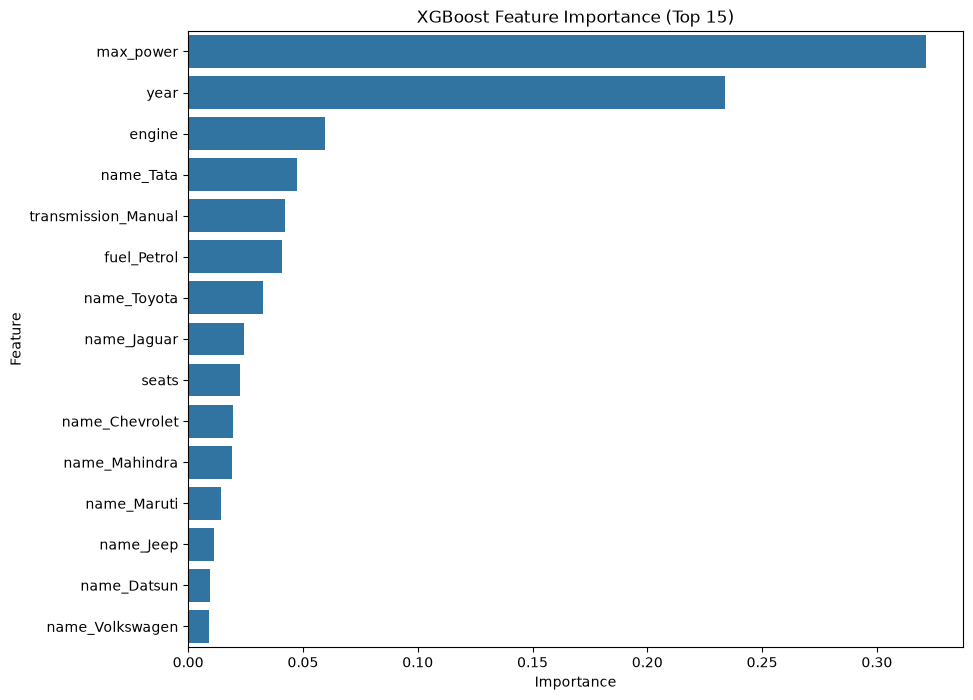

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance (Top 15)")
plt.show()

In [116]:
!pip install joblib


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\User\Downloads\ML ASSIGNMENT 1\venv\Scripts\python.exe -m pip install --upgrade pip


## 9. Model Saving and Prediction

After evaluating the regression models, the trained XGBoost model is selected for deployment because it provides strong predictive performance compared with the other models.

The trained model and preprocessing components are saved using `joblib`, allowing them to be reused later without retraining the model.

The following components are saved:
- The trained XGBoost regression model.
- The `StandardScaler` used during numerical feature scaling.
- The feature-column structure used by the model.

A sample vehicle is then provided as input to demonstrate how the trained model can be used to generate a prediction.

The input data is converted into the same one-hot encoded format used during model training. Since the sample input may not contain every categorical category represented in the training dataset, the encoded input is reindexed using the saved model columns. Missing columns are filled with zero to ensure that the input feature structure matches the model's expected input.

Finally, the processed input is passed to the trained model to generate a predicted selling price.

In [117]:
import joblib

joblib.dump(
    xgb_model,
    "xgboost_car_price_model.pkl"
)

['xgboost_car_price_model.pkl']

In [118]:


joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [119]:
xgb_model = models["XGBoost"]

In [120]:
import joblib

joblib.dump(
    xgb_model,
    "xgb_car_price_model.pkl"
)

['xgb_car_price_model.pkl']

In [121]:
joblib.dump(
    X_train.columns,
    "model_columns.pkl"
)

['model_columns.pkl']

In [ ]:
input_data = pd.DataFrame({
    "name": ["Maruti"],
    "year": [2014],
    "km_driven": [145500],
    "fuel": ["Diesel"],
    "seller_type": ["Individual"],
    "transmission": ["Manual"],
    "owner": [1],
    "mileage": [23.4],
    "engine": [1248],
    "max_power": [74],
    "seats": [5]
})

In [122]:
input_encoded = pd.get_dummies(
    input_data,
    columns=cat_cols,
    drop_first=True
)

In [123]:
model_columns = joblib.load(
    "model_columns.pkl"
)

In [125]:
input_encoded = input_encoded.reindex(
    columns=model_columns,
    fill_value=0
)

In [126]:
prediction = model.predict(input_encoded)

print(prediction[0])

12.978302823744217


In [127]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

## Summary

The most important features for predicting car price are `max_power`, `year`, and `engine`, followed by certain luxury brands like BMW, Mercedes-Benz, and Jaguar. This makes sense because a car’s performance, age, and brand prestige strongly influence its market value. Features such as `seller_type` and `owner` had minimal impact, likely because most cars in the dataset are sold by individuals and the number of previous owners is already correlated with age and mileage.

Among the algorithms tested, XGBoost performed best with an R² of 0.945 and the lowest RMSE (0.198). Random Forest also performed well, confirming that ensemble tree‑based methods capture complex non‑linear relationships better than linear models. Ridge regression was competitive but slightly worse, while Lasso failed completely (R² ≈ 0) because it over‑penalized many dummy variables, discarding useful brand information.

Overall, the model is robust enough for practical use, with an average error of around 0.14 in log‑price (roughly 15% in actual price). The log transformation helped stabilize the variance and improved the performance of all models.

## Repository

The complete code, web application, and trained models are available in this GitHub repository:  
[https://github.com/J-Rodoshi/car-price-prediction](https://github.com/J-Rodoshi/car-price-prediction)

The repository contains:
- `A1.ipynb` – this notebook
- `app/` folder with the Dash web app, Docker files, and model artifacts
- `README.md` with setup instructions